In [7]:
# ==============================================================================
# STEP 1.1: IMPORT LIBRARIES AND CONFIGURE JUPYTER ENVIRONMENT
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning core framework components
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Machine learning validation and baseline metrics evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Configure notebook presentation preferences
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Set random seed to enforce absolute mathematical reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Phase 1.1 setup successful. PyTorch and Data Science environments verified.")

Phase 1.1 setup successful. PyTorch and Data Science environments verified.


In [8]:
# ==============================================================================
# STEP 1.2: INGEST RAW DATASETS FROM THE DATASETS DIRECTORY
# ==============================================================================
# Since my notebooks live inside the 'Notebooks' folder, we look up one directory 
# level '..' and then navigate into the 'Datasets' folder.
DATA_DIR = os.path.join("..", "Datasets")

print(f"Target dataset directory configured to: {DATA_DIR}")
print("Commencing automated raw data file ingestion...")

try:
    # Core Cohort Mapping Tables
    df_edstays   = pd.read_csv(os.path.join(DATA_DIR, "edstays.csv"))
    df_icustays  = pd.read_csv(os.path.join(DATA_DIR, "icustays.csv"))
    
    # Static Agent Tables
    df_triage    = pd.read_csv(os.path.join(DATA_DIR, "triage.csv"))
    df_patients  = pd.read_csv(os.path.join(DATA_DIR, "patients.csv"))
    df_diagnosis = pd.read_csv(os.path.join(DATA_DIR, "diagnosis.csv"))
    
    # Vitals Agent Tables
    df_vitalsign = pd.read_csv(os.path.join(DATA_DIR, "vitalsign.csv"))
    
    # Labs Agent Tables
    df_labevents = pd.read_csv(os.path.join(DATA_DIR, "labevents.csv"))
    df_dlabitems = pd.read_csv(os.path.join(DATA_DIR, "d_labitems.csv"))
    
    print("-" * 60)
    print("SUCCESS: Ingestion completed smoothly.")
    print(f"-> Base Cohort Stays Loaded: {len(df_edstays)}")
    print(f"-> Laboratory Records Loaded: {len(df_labevents)}")
    print(f"-> Patient Demographic Records Loaded: {len(df_patients)}")
    print("-" * 60)
except FileNotFoundError as e:
    print("-" * 60)
    print(f"ERROR: Could not locate a data file. Verify file names match exactly.")
    print(f"System details: {e}")

Target dataset directory configured to: ..\Datasets
Commencing automated raw data file ingestion...
------------------------------------------------------------
SUCCESS: Ingestion completed smoothly.
-> Base Cohort Stays Loaded: 222
-> Laboratory Records Loaded: 107727
-> Patient Demographic Records Loaded: 100
------------------------------------------------------------


PHASE 2: Target Label Engineering & Cohort Extraction.

I am going to write the logic: isolating every Emergency Department encounter (stay_id from df_edstays) and checking if that patient was subsequently admitted to the ICU (df_icustays).

In [9]:
# ==============================================================================
# PHASE 2: TARGET LABEL ENGINEERING & COHORT EXTRACTION
# ==============================================================================

"""
Here we will engineer the ground-truth target
 labels for our early patient deterioration 
prediction task by cross-referencing the ED 
cohort with the ICU cohort. The goal is to create
 a binary label for each ED encounter indicating 
 whether the patient was subsequently admitted to 
 the ICU within a clinically relevant time window 
 (e.g., 24 hours post-ED discharge). 
 This will serve as our target variable for supervised learning.
"""


# Step 2.1:  I Convert all clinical timestamp columns to pandas datetime objects.
# This prevents string comparison errors and enables exact mathematical time math.
df_edstays['intime'] = pd.to_datetime(df_edstays['intime'])
df_edstays['outtime'] = pd.to_datetime(df_edstays['outtime'])
df_icustays['intime'] = pd.to_datetime(df_icustays['intime'])
df_icustays['outtime'] = pd.to_datetime(df_icustays['outtime'])

print("Timestamps successfully parsed into datetime format.")

# Step 2.2: Build the ground-truth binary target outcome array.
# We map through our ED cohort and search for a corresponding ICU validation match. if a match is found, we label the encounter as a positive deterioration case (1), otherwise as a stable control case (0).
target_labels = []
icu_intimes = []

for idx, ed_row in df_edstays.iterrows():
    p_id = ed_row['subject_id']
    ed_out = ed_row['outtime']
    
    # Query icustays to see if this specific patient ever went to the ICU
    patient_icu_trips = df_icustays[df_icustays['subject_id'] == p_id]
    
    is_icu_admission = 0
    matched_icu_time = pd.NaT # this is a placeholder for cases where no ICU admission is found
    
    if not patient_icu_trips.empty:
        # Check if any ICU admission happened AFTER or at the exact time of ED arrival
        # and within a reasonable critical window (e.g., up to 24 hours post-ED discharge)
        for _, icu_row in patient_icu_trips.iterrows():
            icu_in = icu_row['intime']
            
            # If the ICU admission falls after ED entry and within 24 hours of leaving the ED
            if icu_in >= ed_row['intime'] and (icu_in - ed_out) <= pd.Timedelta(hours=24):
                is_icu_admission = 1
                matched_icu_time = icu_in
                break # Label confirmed for this encounter; exit loop
                
    target_labels.append(is_icu_admission)
    icu_intimes.append(matched_icu_time)

# Step 2.3: Consolidate the extracted metrics into a clean master cohort DataFrame
df_cohort = df_edstays[['subject_id', 'stay_id', 'intime', 'outtime']].copy()
df_cohort['target_icu'] = target_labels
df_cohort['icu_intime'] = icu_intimes

print("-" * 50)
print(f"Cohort Generation Complete. Total Encounters: {len(df_cohort)}")
print(f"Positive Deterioration Cases (ICU Admission = 1): {df_cohort['target_icu'].sum()}")
print(f"Stable Control Cases (ICU Admission = 0): {len(df_cohort) - df_cohort['target_icu'].sum()}")
print("-" * 50)

# Display a preview of your structured cohort framework
df_cohort.head(200)

Timestamps successfully parsed into datetime format.
--------------------------------------------------
Cohort Generation Complete. Total Encounters: 222
Positive Deterioration Cases (ICU Admission = 1): 64
Stable Control Cases (ICU Admission = 0): 158
--------------------------------------------------


,subject_id,stay_id,intime,outtime,target_icu,icu_intime
0,10014729,37887480,2125-03-19 12:36:00,2125-03-19 16:59:47,0,NaT
1,10018328,34176810,2154-02-05 17:09:00,2154-02-05 22:54:00,0,NaT
2,10018328,32103106,2154-08-03 15:31:00,2154-08-03 22:29:00,0,NaT
3,10020640,38797992,2153-02-12 21:59:00,2153-02-13 01:38:00,1,2153-02-13 01:38:00
4,10015272,33473053,2137-06-12 16:54:00,2137-06-12 18:37:22,1,2137-06-12 18:37:22
...,...,...,...,...,...,...
195,10014354,30094124,2147-11-14 18:22:00,2147-11-14 23:09:00,0,NaT
196,10014354,35205519,2148-06-29 21:06:00,2148-06-30 02:27:00,1,2148-06-30 02:27:00
197,10022041,36715666,2187-05-18 14:59:00,2187-05-18 18:39:00,1,2187-05-18 18:39:00
198,10026406,39571461,2129-11-25 19:02:00,2129-11-26 00:46:00,0,NaT


FEATURE PIPELINING & DATA SPLICING. 
I Build Static Features, combining baseline patient variables from df_edstays (demographics), df_triage (acuity and intake vitals), and df_diagnosis (comorbidities/initial impressions)

In [10]:
# ==============================================================================
# PHASE 3: FEATURE PIPELINING - STEP 3.1: STATIC FEATURE ENGINEERING
# ==============================================================================

print("Commencing static master feature matrix construction...")

# 1. Start with our master cohort framework as the base
df_static = df_cohort[['subject_id', 'stay_id', 'target_icu', 'icu_intime']].copy()

# 2. Extract and merge demographic features from df_edstays
df_demographics = df_edstays[['stay_id', 'gender', 'race', 'arrival_transport']].copy()
df_static = pd.merge(df_static, df_demographics, on='stay_id', how='left')

# 3. Clean up the 'race' column by grouping rare categories to prevent feature explosion
def simplify_race(race_string):
    if pd.isna(race_string):
        return 'UNKNOWN'
    race_upper = str(race_string).upper()
    if 'WHITE' in race_upper:
        return 'WHITE'
    elif 'BLACK' in race_upper:
        return 'BLACK'
    elif 'HISPANIC' in race_upper or 'LATINO' in race_upper:
        return 'HISPANIC'
    elif 'ASIAN' in race_upper:
        return 'ASIAN'
    else:
        return 'OTHER_UNKNOWN'

df_static['race_cleaned'] = df_static['race'].apply(simplify_race)
df_static.drop(columns=['race'], inplace=True) # we delet the previous race column to avoid redundancy

# 4. Extract and merge baseline structural triage clinical signals 
# Converting 'pain' values to numerical scores, setting unexpected codes (like 'UA') to a baseline 0
df_triage_features = df_triage[[
    'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity'
]].copy()

df_triage_features['pain_numeric'] = pd.to_numeric(df_triage_features['pain'], errors='coerce').fillna(0)
df_triage_features.drop(columns=['pain'], inplace=True)

df_static = pd.merge(df_static, df_triage_features, on='stay_id', how='left')

# 5. Extract key static risk flags from high-priority early diagnoses (e.g., Sepsis/Shock indicators)
# We flag 1 if the patient has any record containing 'SEPTIC' or 'SHOCK' in their initial evaluation
sepsis_shock_stays = df_diagnosis[
    df_diagnosis['icd_title'].str.contains('SEPTIC|SHOCK|SEPSIS', case=False, na=False)
]['stay_id'].unique() # this will give us a unique list of stay_ids that have sepsis or shock diagnoses

df_static['flag_sepsis_shock_hx'] = df_static['stay_id'].isin(sepsis_shock_stays).astype(int) # This creates a binary indicator for sepsis/shock history

# 6. Apply standard mean-imputation for any missing baseline intake triage scores
numerical_static_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'acuity']
for col in numerical_static_cols:
    mean_val = df_static[col].mean() 
    df_static[col] = df_static[col].fillna(mean_val)

# 7. One-Hot Encode our categorical indicators for the Static Neural Agent
categorical_cols = ['gender', 'arrival_transport', 'race_cleaned']
df_static = pd.get_dummies(df_static, columns=categorical_cols, drop_first=True, dtype=int)

print("-" * 50)
print(f"Static Feature Pipeline Finished. Cleaned Matrix Shape: {df_static.shape}")
print("-" * 50)

# Display a preview of the structured vector ready for your Static Agent MLP
df_static.head()
X_static = df_static.drop(columns=['subject_id', 'stay_id', 'target_icu', 'icu_intime']).values

Commencing static master feature matrix construction...
--------------------------------------------------
Static Feature Pipeline Finished. Cleaned Matrix Shape: (222, 20)
--------------------------------------------------


We will now write a robust preprocessing loop that builds an exact $8$-hour sequential look-back window for every patient. If a patient deteriorates or is discharged before 8 hours, we capture their available timeline. This processed sequence will serve as the exact training matrix for our Vitals Sequential Agent.

In [11]:
# ==============================================================================
# PHASE 3: FEATURE PIPELINING - STEP 3.2 & 3.3: TIME-SERIES SEQUENCE RESHAPING OF ViTAL SIGNS features
# ==============================================================================
"""
In this step, we will transform the high-frequency
 vital sign measurements into a structured 3D tensor 
 suitable for sequential deep learning models. 
 Each patient encounter will be represented as a 
 matrix of shape (MAX_HOURS, VITAL_FEATURES), where MAX_HOURS
   is the number of discrete hourly bins we consider,
     and VITAL_FEATURES are the physiological measurements we track.

"""
print("Initializing hourly regularized time-series processing loop...")

# We Define structural hyperparameters for our sequential deep learning architecture
MAX_HOURS = 8  # Look-back window length: We look at the first 8 hours of the ED stay
VITAL_FEATURES = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

# This master list will hold a 2D array (Hours x Features) for every single patient encounter
sequential_tensor_list = []
valid_stay_ids = []

# Core loop: Process each patient's timeline relative to their unique ED entry time (t_0)
for idx, cohort_row in df_cohort.iterrows(): # iterrows() is used to iterate over each row in the DataFrame, providing both the index and the row data as a Series.
    s_id = cohort_row['stay_id']
    t_0 = cohort_row['intime']  # This represent the time the patient entered the ED and serves as our reference point for all subsequent vital sign measurements.
    
    # --------------------------------------------------------------------------
    # 1. EXTRACT PATIENT-SPECIFIC RECORDS
    # --------------------------------------------------------------------------
    # Isolate all high-frequency vital sign entries logged for this specific visit
    p_vitals = df_vitalsign[df_vitalsign['stay_id'] == s_id].copy()
    
    if p_vitals.empty:
        # If a patient has absolutely no dynamic vitals logged, skip to maintain data integrity
        continue
        
    # Enforce date-time format for chronological sorting
    p_vitals['charttime'] = pd.to_datetime(p_vitals['charttime'])
    
    # Calculate the exact elapsed operational time delta in hours since arrival (t_0)
    p_vitals['elapsed_hours'] = (p_vitals['charttime'] - t_0).dt.total_seconds() / 3600.0
    
    # --------------------------------------------------------------------------
    # 2. HOURLY UNIFORM BINNING
    # --------------------------------------------------------------------------
    # Drop records recorded prior to official admission or past our max look-back window
    p_vitals = p_vitals[(p_vitals['elapsed_hours'] >= 0) & (p_vitals['elapsed_hours'] <= MAX_HOURS)]
    
    # Round up the fractional hours to map measurements into discrete 1-hour index bins
    p_vitals['hour_bin'] = np.ceil(p_vitals['elapsed_hours']).astype(int) # this ensures that any measurement taken at 0.1 hours is considered part of Hour 1, and so on.
    # Ensure hour 0 drops map into bin 1
    p_vitals.loc[p_vitals['hour_bin'] == 0, 'hour_bin'] = 1 # This ensures that any measurement taken at 0.0 hours is considered part of Hour 1, and so on.
    
    # Group by the discrete hour bin and take the mathematical mean of measurements within that hour
    hourly_binned_vitals = p_vitals.groupby('hour_bin')[VITAL_FEATURES].mean() # This will give us a DataFrame with index as hour_bin and columns as VITAL_FEATURES
    # Hour bin  is now the index, and we have a mean value for each vital sign in that hour.
    # hour bin is gotten by rounding up the elapsed hours, so any measurement taken at 0.1 hours is considered part of Hour 1, and so on.
    # Full meaning of hour bin is that it represents the average of all measurements taken between (i-1, i] hours since ED arrival.

    # --------------------------------------------------------------------------
    # 3. CONSTRUCT BALANCED BLANK MATRIX (Size: MAX_HOURS x Features)
    # --------------------------------------------------------------------------
    # Create an empty template full of NaNs covering exactly Hour 1 to Hour MAX_HOURS
    template_df = pd.DataFrame(index=range(1, MAX_HOURS + 1), columns=VITAL_FEATURES)
    
    # Overlay our actual calculated binned vitals on top of the empty template
    templated_vitals = template_df.combine_first(hourly_binned_vitals) # this will fill in the known values and leave NaNs where we have no data
    
    # --------------------------------------------------------------------------
    # 4. FORWARD-FILLING IMPUTATION & COHORT MEAN BACKFILL
    # --------------------------------------------------------------------------
    # LOCF (Last Observation Carried Forward): Propagate the last known measurement down the timeline
    templated_vitals.ffill(inplace=True) # This ensures that if a patient has a measurement at Hour 2, it will be carried forward to Hour 3, 4, etc., until a new measurement is recorded.
    
    # If the patient has no initial measurement at hour 1, fill it using global cohort averages
    # This prevents NaN propagation downstream into our PyTorch layers
    for feature in VITAL_FEATURES:
        global_mean = df_vitalsign[feature].mean()
        templated_vitals[feature].fillna(global_mean, inplace=True)
    
    

    # --------------------------------------------------------------------------
    # 5. CONVERT TO NUMPY MATRIX & RE-VALIDATE SHAPE
    # --------------------------------------------------------------------------
    # Extract raw values to create a smooth numpy matrix shape: (8, 6)
    matrix_representation = templated_vitals.values
    
    sequential_tensor_list.append(matrix_representation)
    valid_stay_ids.append(s_id) # This ensures we only keep stay_ids for which we have valid sequential data

# Convert our list of matrices into a single master 3D NumPy array for deep learning
X_sequential = np.stack(sequential_tensor_list, axis=0)

print("-" * 50)
print("Sequential Processing Pipeline Completed Successfully.")
print(f"Master Sequential Tensor Shape: {X_sequential.shape}")
print(f"Interpretation: {X_sequential.shape[0]} patient trajectories, "
      f"each tracked across {X_sequential.shape[1]} distinct hours, "
      f"evaluating {X_sequential.shape[2]} physiological features.")
print("-" * 50)

print(templated_vitals)
#print(X_sequential)

"""
what is the target label for each patient in the sequential tensor?
answer: The target label for each patient in the sequential tensor corresponds 
to the binary outcome of whether the patient was admitted to the ICU within a 
clinically relevant time window (e.g., 24 hours post-ED discharge).
 This label is derived from the 'target_icu' column in the df_cohort DataFrame, 
 where a value of 1 indicates a positive deterioration case (ICU admission) and 
 a value of 0 indicates a stable control case (no ICU admission). 
 Each entry in the sequential tensor aligns with the corresponding patient 
 encounter's target label.
"""


Initializing hourly regularized time-series processing loop...


C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\2753745619.py:81: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  templated_vitals[feature].fillna(global_mean, inplace=True)
C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\2753745619.py:81: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chain

--------------------------------------------------
Sequential Processing Pipeline Completed Successfully.
Master Sequential Tensor Shape: (206, 8, 6)
Interpretation: 206 patient trajectories, each tracked across 8 distinct hours, evaluating 6 physiological features.
--------------------------------------------------
  temperature heartrate resprate o2sat    sbp   dbp
1         NaN       NaN      NaN   NaN    NaN   NaN
2         NaN       NaN      NaN   NaN    NaN   NaN
3         NaN       NaN      NaN   NaN    NaN   NaN
4         NaN       NaN      NaN   NaN    NaN   NaN
5         NaN       NaN      NaN   NaN    NaN   NaN
6        97.3      93.0     16.0   NaN  139.0  83.0
7        97.3      93.0     16.0   NaN  139.0  83.0
8        97.3      93.0     16.0   NaN  139.0  83.0


C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\2753745619.py:81: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  templated_vitals[feature].fillna(global_mean, inplace=True)


"\nwhat is the target label for each patient in the sequential tensor?\nanswer: The target label for each patient in the sequential tensor corresponds \nto the binary outcome of whether the patient was admitted to the ICU within a \nclinically relevant time window (e.g., 24 hours post-ED discharge).\n This label is derived from the 'target_icu' column in the df_cohort DataFrame, \n where a value of 1 indicates a positive deterioration case (ICU admission) and \n a value of 0 indicates a stable control case (no ICU admission). \n Each entry in the sequential tensor aligns with the corresponding patient \n encounter's target label.\n"

In [12]:
# ==============================================================================
# PHASE 3: FEATURE PIPELINING - STEP 3.4: LABS SEQUENCE RESHAPING
# ==============================================================================

"""
here we will transform the laboratory test results into a structured 3D tensor
 suitable for sequential deep learning models.
 Each patient encounter will be represented as a matrix of shape (MAX HOURS, LAB_FEATURES),
where MAX_HOURS is the number of discrete hourly bins we consider, and LAB_FEATURES are 
the laboratory measurements we track.
"""

print("Initializing hourly regularized lab-series processing loop...")

# Define structure parameters for our sequential Labs Neural Agent
MAX_HOURS = 8  

# We will select 5 critical prognostic lab markers commonly evaluated during triage
# Note: In production, we can expand this list using itemid mappings from d_labitems
LAB_FEATURES = ['lactate', 'wbc', 'creatinine', 'hemoglobin', 'platelet']

# Enforce uniform date-time parsing for the lab events dataset
df_labevents['charttime'] = pd.to_datetime(df_labevents['charttime'])
df_cohort['intime'] = pd.to_datetime(df_cohort['intime'])

labs_tensor_list = []
valid_lab_stay_ids = []

# Mock up columns for this demonstration slice if our lab file uses a wide format; 
# otherwise, map long-form itemid markers directly. Here we process a standard clean layout:
for idx, cohort_row in df_cohort.iterrows():
    s_id = cohort_row['stay_id']
    p_id = cohort_row['subject_id']
    t_0 = cohort_row['intime']
    
    # Isolate lab values drawn for this specific patient
    p_labs = df_labevents[df_labevents['subject_id'] == p_id].copy()
    
    # If a patient lacks lab data entirely, we generate a placeholder matrix filled with cohort means
    if p_labs.empty:
        p_labs = pd.DataFrame(columns=['charttime'] + LAB_FEATURES)
        
    p_labs['elapsed_hours'] = (p_labs['charttime'] - t_0).dt.total_seconds() / 3600.0
    
    # Filter records strictly within our target 8-hour ED analysis window
    p_labs = p_labs[(p_labs['elapsed_hours'] >= 0) & (p_labs['elapsed_hours'] <= MAX_HOURS)]
    
    # Map to hourly discrete index bins
    p_labs['hour_bin'] = np.ceil(p_labs['elapsed_hours']).astype(int)
    p_labs.loc[p_labs['hour_bin'] == 0, 'hour_bin'] = 1
    
    # Deduplicate multiple records in a single hour by calculating the hourly average
    # If columns don't exist yet in your raw slice, pandas handles the template generation smoothly
    available_cols = [c for c in LAB_FEATURES if c in p_labs.columns]
    if available_cols:
        hourly_binned_labs = p_labs.groupby('hour_bin')[available_cols].mean()
    else:
        hourly_binned_labs = pd.DataFrame(index=range(1, MAX_HOURS + 1), columns=LAB_FEATURES)
        
    # Overlay onto our rigid MAX_HOURS x Features framework template
    template_df = pd.DataFrame(index=range(1, MAX_HOURS + 1), columns=LAB_FEATURES)
    templated_labs = template_df.combine_first(hourly_binned_labs)
    
    # Imputation Strategy: Last Observation Carried Forward (LOCF)
    templated_labs.ffill(inplace=True)
    
    # Backfill lingering gaps using standardized baseline values to protect backpropagation lines
    for feature in LAB_FEATURES:
        # Fallback normal clinical baselines if the demo file column is completely blank
        fallback_value = df_labevents[feature].mean() if feature in df_labevents.columns else 1.0
        templated_labs[feature].fillna(fallback_value, inplace=True)
        
    # Extract numerical matrix shape: (8, 5)
    labs_matrix = templated_labs.values
    labs_tensor_list.append(labs_matrix)
    valid_lab_stay_ids.append(s_id)

# Compress individual trajectory matrices into a unified 3D NumPy array
X_labs = np.stack(labs_tensor_list, axis=0)

print("-" * 60)
print("Labs Sequential Feature Processing Complete.")
print(f"Master Labs Tensor Shape: {X_labs.shape}")
print(f"Interpretation: {X_labs.shape[0]} patient lab trajectories, "
      f"each tracked across {X_labs.shape[1]} discrete hours, "
      f"modeling {X_labs.shape[2]} specialized metabolic/biomarker features.")
print("-" * 60)

C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\698653291.py:71: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  templated_labs[feature].fillna(fallback_value, inplace=True)
C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\698653291.py:71: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

Initializing hourly regularized lab-series processing loop...


C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\698653291.py:71: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  templated_labs[feature].fillna(fallback_value, inplace=True)
C:\Users\gideo\AppData\Local\Temp\ipykernel_57540\698653291.py:71: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

------------------------------------------------------------
Labs Sequential Feature Processing Complete.
Master Labs Tensor Shape: (222, 8, 5)
Interpretation: 222 patient lab trajectories, each tracked across 8 discrete hours, modeling 5 specialized metabolic/biomarker features.
------------------------------------------------------------


Now that we have successfully structured our feature matrices for all three modalities and established the conceptual framework, we are ready for PHASE 4: UNIMODAL EXPERT NEURAL AGENTS.

In this phase, we will write the formal PyTorch model definitions for our three independent unimodal networks: the Static Agent, the Vitals Agent, and the Labs Agent.

In [13]:
# ==============================================================================
# PHASE 4: UNIMODAL EXPERT NEURAL AGENTS DEFINITION
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Initializing PyTorch Model Definitions for Unimodal Agents...")

# --------------------------------------------------------------------------
# 1. STATIC NEURAL AGENT (Multi-Layer Perceptron)
# --------------------------------------------------------------------------
class StaticAgent(nn.Module):
    """
    The Static Agent is a Multi-Layer Perceptron (MLP) designed to extract
    stationary clinical risk representations from patient demographics, triage
    vitals, and baseline admission profiles.
    """
    def __init__(self, input_dim, embedding_dim=16):
        super(StaticAgent, self).__init__()
        
        # We construct a 3-layer deep network with batch normalization to stabilize
        # the scale of continuous values and Dropout to prevent overfitting.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            # The final layer outputs a clean latent embedding vector representing
            # the patient's baseline stationary risk signature.
            nn.Linear(32, embedding_dim)
        )
        
    def forward(self, x):
        # x shape: (Batch Size, input_dim)
        return self.network(x)


# --------------------------------------------------------------------------
# 2. VITALS NEURAL AGENT (LSTM with Monte Carlo Dropout)
# --------------------------------------------------------------------------
class VitalsAgent(nn.Module):
    """
    The Vitals Agent uses a Recurrent LSTM network to ingest high-frequency,
    continuous vital sign trajectories. It incorporates active Monte Carlo (MC)
    Dropout to capture and quantify prediction uncertainty.
    """
    def __init__(self, input_dim, hidden_dim=32, embedding_dim=16, num_layers=1): 
        super(VitalsAgent, self).__init__()
        self.hidden_dim = hidden_dim 
        self.num_layers = num_layers
        
        # LSTM layer to process temporal dependencies over the 8-hour window
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Fully connected layer to project the final hidden state into a latent embedding
        self.fc = nn.Linear(hidden_dim, embedding_dim)
        
        # Dropouts used for MC uncertainty estimation
        self.lstm_dropout = nn.Dropout(p=0.2)
        self.fc_dropout = nn.Dropout(p=0.2)

    def forward(self, x, force_mc_dropout=False):
        # x shape: (Batch Size, Sequence Length (8), input_dim (6))
        lstm_out, (hn, cn) = self.lstm(x)
        
        # Extract the final hidden state of the LSTM sequence
        out = hn[-1]
        
        # Apply dropout. If force_mc_dropout=True, dropout remains active during testing
        if force_mc_dropout:
            out = F.dropout(out, p=0.2, training=True)
        else:
            out = self.lstm_dropout(out)
            
        # Project representation to embedding dimension
        embedding = self.fc(out)
        
        if force_mc_dropout:
            embedding = F.dropout(embedding, p=0.2, training=True)
        else:
            embedding = self.fc_dropout(embedding)
            
        return embedding


# --------------------------------------------------------------------------
# 3. LABS NEURAL AGENT (LSTM with Monte Carlo Dropout)
# --------------------------------------------------------------------------
class LabsAgent(nn.Module):
    """
    The Labs Agent processes sparse, multi-hour biochemical marker records.
    Like the Vitals Agent, it uses recurrent layers and Monte Carlo Dropout
    to estimate confidence boundaries over sparse data sequences.
    """
    def __init__(self, input_dim, hidden_dim=32, embedding_dim=16, num_layers=1):
        super(LabsAgent, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM layer to model metabolic biomarker trajectories
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Fully connected projection layer
        self.fc = nn.Linear(hidden_dim, embedding_dim)
        
        self.lstm_dropout = nn.Dropout(p=0.3)
        self.fc_dropout = nn.Dropout(p=0.3)

    def forward(self, x, force_mc_dropout=False):
        # x shape: (Batch Size, Sequence Length (8), input_dim (5))
        lstm_out, (hn, cn) = self.lstm(x)
        
        # Isolate the final sequential hidden state
        out = hn[-1]
        
        # Apply dropout. MC active switches force dropout during test evaluations
        if force_mc_dropout:
            out = F.dropout(out, p=0.3, training=True)
        else:
            out = self.lstm_dropout(out)
            
        embedding = self.fc(out)
        
        if force_mc_dropout:
            embedding = F.dropout(embedding, p=0.3, training=True)
        else:
            embedding = self.fc_dropout(embedding)
            
        return embedding

print("-" * 60)
print("SUCCESS: All 3 Unimodal Expert Agent classes declared and loaded.")
print("-" * 60)

Initializing PyTorch Model Definitions for Unimodal Agents...
------------------------------------------------------------
SUCCESS: All 3 Unimodal Expert Agent classes declared and loaded.
------------------------------------------------------------


We have our individual unimodal expert agents declared. Now, we must implement the crowning jewel of your research architecture: PHASE 5: THE CENTRAL NEURAL COORDINATOR.

This is the master decision-making network that fuses the representations from the Static, Vitals, and Labs agents while dynamically adjusting its attention based on their prediction uncertainty.

In [14]:
# ==============================================================================
# PHASE 5: THE CENTRAL NEURAL COORDINATOR DEFINITION
# ==============================================================================
import torch
import torch.nn as nn

print("Initializing PyTorch Model Definition for the Central Neural Coordinator...")

class CentralNeuralCoordinator(nn.Module):
    """
    The Central Neural Coordinator acts as the master decision-making layer.
    It takes the latent embedding vectors from all three sub-agents and fuses 
    them using an uncertainty-gated mechanism. If an agent (e.g., Labs) expresses
    high variance (uncertainty) due to missing or noisy data, the coordinator
    dynamically down-weights its influence on the final clinical prediction.
    """
    def __init__(self, static_dim=16, vitals_dim=16, labs_dim=16):
        super(CentralNeuralCoordinator, self).__init__()
        
        # 1. Gating Networks: Learnable linear layers that evaluate the uncertainty 
        # of the Vitals and Labs agents to output a gating scalar between 0 and 1.
        # Inputs: The agent's uncertainty variance (1D scalar).
        # Output: A weight scaling factor.
        self.vitals_gate = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
        self.labs_gate = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
        # 2. Multimodal Fusion Layers: Once gated, we concatenate the embeddings.
        # Total concatenated dimension: 16 (Static) + 16 (Vitals) + 16 (Labs) = 48
        total_fused_dim = static_dim + vitals_dim + labs_dim
        
        self.fusion_network = nn.Sequential(
            nn.Linear(total_fused_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            
            # Final output node projecting to a single risk probability logit
            nn.Linear(32, 1)
        )
        
    def forward(self, static_emb, vitals_emb, vitals_variance, labs_emb, labs_variance):
        """
        Args:
            static_emb: (Batch, 16) - Baseline risk embedding (deterministic)
            vitals_emb: (Batch, 16) - Sequential vitals embedding (mean)
            vitals_variance: (Batch, 1) - Epistemic uncertainty from MC Dropout
            labs_emb: (Batch, 16) - Sequential labs embedding (mean)
            labs_variance: (Batch, 1) - Epistemic uncertainty from MC Dropout
        """
        # Step A: Compute dynamic attention/gate weights based on uncertainty.
        # High variance (uncertainty) results in a gating weight closer to 0.
        # We invert the signal so higher uncertainty decreases the gate output.
        v_weight = self.vitals_gate(-vitals_variance)
        l_weight = self.labs_gate(-labs_variance)
        
        # Step B: Apply the learned gate weights to scale the latent embeddings.
        # If the Labs sequence is highly uncertain, its entire embedding is scaled down.
        weighted_vitals = vitals_emb * v_weight
        weighted_labs = labs_emb * l_weight
        
        # Step C: Concatenate the static representation with the gated sequential representations
        # Shape: (Batch Size, 48)
        fused_vector = torch.cat([static_emb, weighted_vitals, weighted_labs], dim=1)
        
        # Step D: Pass the fused multi-agent matrix through the classification layers
        logits = self.fusion_network(fused_vector)
        
        # Step E: Apply Sigmoid to output a calibrated probability of ICU deterioration
        probability = torch.sigmoid(logits)
        
        return probability, v_weight, l_weight

print("-" * 60)
print("SUCCESS: Central Neural Coordinator Class successfully loaded.")
print("-" * 60)

Initializing PyTorch Model Definition for the Central Neural Coordinator...
------------------------------------------------------------
SUCCESS: Central Neural Coordinator Class successfully loaded.
------------------------------------------------------------


Now that our model classes—the three unimodal agents and the central coordinator—are fully defined, we must implement PHASE 6: THE PYTORCH MULTIMODAL DATASET & LOADER.

why we are doing it, and the deep-learning concepts behind this step.

The Concepts Behind a Multimodal DatasetThe ProblemTypically, a standard PyTorch training loop handles a single input array (like an image matrix or a flat tabular matrix) paired with a target label ($X \rightarrow Y$). In our architecture, we have a multimodal setup. For every single patient encounter, our training loop needs to access:
1. X_static: A 1D tabular vector.
2. X_vitals: A 3D temporal matrix of shape $(8, 6)
3. X_labs: A 3D temporal matrix of shape $(8, 5)$.
4. Y: The binary classification label (0 or 1).

In [15]:
# ==============================================================================
# PHASE 6: MULTIMODAL DATASET PIPELINE
# ==============================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

print("Initializing Multimodal PyTorch Dataset Engine...")

class ClinicalMultimodalDataset(Dataset):
    """
    A unified dataset class that coordinates our three independent data streams.
    It maps static tabular arrays, dynamic vitals tensors, and sparse lab tensors
    to their corresponding binary clinical outcome targets for every unique stay.
    """
    def __init__(self, static_data, vitals_data, labs_data, targets):
        # Convert all input arrays to standard PyTorch FloatTensors
        # and targets to a FloatTensor shape suited for Binary Cross Entropy Loss (BCE)
        self.static_tensor = torch.tensor(static_data, dtype=torch.float32)
        self.vitals_tensor = torch.tensor(vitals_data, dtype=torch.float32)
        self.labs_tensor   = torch.tensor(labs_data, dtype=torch.float32)
        self.target_tensor = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)
        
        # Verify alignment integrity across all modalities
        assert len(self.static_tensor) == len(self.vitals_tensor) == len(self.labs_tensor) == len(self.target_tensor), \
            "Data alignment mismatch! Ensure static, vitals, labs, and targets have identical sample lengths."

    def __len__(self):
        # Returns the total number of aligned patient trajectories in the cohort
        return len(self.target_tensor)

    def __getitem__(self, idx):
        # Extract the specific patient profile at index 'idx' across all modalities
        static_sample = self.static_tensor[idx]
        vitals_sample = self.vitals_tensor[idx]
        labs_sample   = self.labs_tensor[idx]
        target_sample = self.target_tensor[idx]
        
        # Return a dictionary container keeping the multimodal inputs cleanly labeled
        return {
            'static': static_sample,
            'vitals': vitals_sample,
            'labs': labs_sample,
            'target': target_sample
        }

print("-" * 60)
print("SUCCESS: ClinicalMultimodalDataset pipeline compiled successfully.")
print("-" * 60)

Initializing Multimodal PyTorch Dataset Engine...
------------------------------------------------------------
SUCCESS: ClinicalMultimodalDataset pipeline compiled successfully.
------------------------------------------------------------


Step 6.2 Implementation: Splitting & Loading the Batches
Now, let's write the execution code. We will split our cohort into 80% Training (to optimize network weights) and 20% Testing (to evaluate performance on unseen patients). We will then spin up optimized batch loaders using PyTorch's DataLoader.

In [16]:
# ==============================================================================
# ALIGNING DATASETS TO THE SMALLEST COMMON SUBSET (N = 206)
# ==============================================================================
# We determine the minimum number of samples present across our feature arrays
min_samples = min(len(X_static), len(X_sequential), len(X_labs), len(df_cohort))

print(f"Aligning all modalities to a uniform cohort size of: {min_samples}")

# Slice all arrays to ensure they align perfectly on Axis 0
X_static_aligned     = X_static[:min_samples]
X_sequential_aligned = X_sequential[:min_samples]
X_labs_aligned       = X_labs[:min_samples]

# Re-extract target labels from the aligned cohort rows
Y_aligned = df_cohort['target_icu'].values[:min_samples]

print("Alignment complete! Verifying shapes:")
print(f"-> Static Features:     {X_static_aligned.shape}")
print(f"-> Vitals Trajectories: {X_sequential_aligned.shape}")
print(f"-> Labs Trajectories:   {X_labs_aligned.shape}")
print(f"-> Targets:            {Y_aligned.shape}")

Aligning all modalities to a uniform cohort size of: 206
Alignment complete! Verifying shapes:
-> Static Features:     (206, 16)
-> Vitals Trajectories: (206, 8, 6)
-> Labs Trajectories:   (206, 8, 5)
-> Targets:            (206,)


In [17]:
# ==============================================================================
# FORCE NUMERICAL CASTING AND CLEANING FOR PYTORCH (CORRECTED)
# ==============================================================================
import numpy as np
import pandas as pd

def clean_and_cast_to_float(array_data, array_name="Array"):
    print(f"Casting {array_name}... Original Type: {array_data.dtype}")
    
    # 1. If it's an object array, check if it's ragged (nested arrays)
    if array_data.dtype == np.object_:
        try:
            # Attempt to stack if it's a list of equal-sized arrays
            array_data = np.stack(list(array_data), axis=0)
            print(f"-> Successfully stacked ragged list for {array_name} into shape: {array_data.shape}")
        except ValueError as e:
            raise ValueError(
                f"Error stacking {array_name}. This usually means your sequential matrices "
                f"do not all have the exact same shape (e.g., some are not 8x6). Check shape sizes! Details: {e}"
            )
            
    # 2. Force conversion to numeric values, converting strings/text to NaN
    flat_data = array_data.ravel()
    numeric_flat = pd.to_numeric(flat_data, errors='coerce')
    
    # If pd.to_numeric returned a Pandas Series, extract its raw values; otherwise use directly
    if hasattr(numeric_flat, 'values'):
        numeric_array = numeric_flat.values.reshape(array_data.shape)
    else:
        numeric_array = numeric_flat.reshape(array_data.shape)
    
    # 3. Fill any newly created NaNs with 0.0 to protect PyTorch backpropagation
    if np.isnan(numeric_array).any():
        print(f"-> Warning: Found NaN values in {array_name}. Imputing with 0.0.")
        numeric_array = np.nan_to_num(numeric_array, nan=0.0)
        
    return numeric_array.astype(np.float32)

# Apply the clean casting
X_sequential_clean = clean_and_cast_to_float(X_sequential_aligned, "Vitals Array")
X_labs_clean       = clean_and_cast_to_float(X_labs_aligned, "Labs Array")
X_static_clean     = clean_and_cast_to_float(X_static_aligned, "Static Array")

print("-" * 60)
print("SUCCESS: All feature sets strictly cast to float32.")
print(f"-> Static:   {X_static_clean.dtype} | Shape: {X_static_clean.shape}")
print(f"-> Vitals:   {X_sequential_clean.dtype} | Shape: {X_sequential_clean.shape}")
print(f"-> Labs:     {X_labs_clean.dtype} | Shape: {X_labs_clean.shape}")
print("-" * 60)

Casting Vitals Array... Original Type: object
-> Successfully stacked ragged list for Vitals Array into shape: (206, 8, 6)
-> Warning: Found NaN values in Vitals Array. Imputing with 0.0.
Casting Labs Array... Original Type: object
-> Successfully stacked ragged list for Labs Array into shape: (206, 8, 5)
-> Warning: Found NaN values in Labs Array. Imputing with 0.0.
Casting Static Array... Original Type: float64
------------------------------------------------------------
SUCCESS: All feature sets strictly cast to float32.
-> Static:   float32 | Shape: (206, 16)
-> Vitals:   float32 | Shape: (206, 8, 6)
-> Labs:     float32 | Shape: (206, 8, 5)
------------------------------------------------------------


In [18]:
# ==============================================================================
# PHASE 6.2: COHORT SPLITTING & PYTORCH DATALOADER GENERATION
# ==============================================================================
from sklearn.model_selection import train_test_split
print("Beginning stratified clinical cohort division (80/20 train/test)...")



# Gather the shapes of our existing prepared arrays to align indexing
# Note: Ensure you have executed the preprocessing steps for X_static, X_sequential (vitals), and X_labs
# Here we extract indices to ensure our splits are perfectly aligned across all three dimensions
indices = np.arange(len(Y_aligned))

# Perform Stratified Train/Test Split
# Why Stratified? Because our target cohort contains 64 deterioration events out of 222 samples,
# we must use stratification to ensure the ratio of stable to deteriorating patients is identical
# in both the training and testing sets. This prevents model training bias.
train_idx, test_idx = train_test_split(
    indices, 
    test_size=0.20, 
    random_state=42, 
    stratify=Y_aligned
)

# Subset our structured multimodal arrays using the generated aligned indices
X_static_train, X_static_test = X_static_clean[train_idx], X_static_clean[test_idx]
X_vitals_train, X_vitals_test = X_sequential_clean[train_idx], X_sequential_clean[test_idx]
X_labs_train, X_labs_test     = X_labs_clean[train_idx], X_labs_clean[test_idx]
Y_train, Y_test               = Y_aligned[train_idx], Y_aligned[test_idx]

# Instantiate our custom training dataset
train_dataset = ClinicalMultimodalDataset(
    static_data=X_static_train, 
    vitals_data=X_vitals_train, 
    labs_data=X_labs_train, 
    targets=Y_train
)

# Instantiate our custom testing dataset
test_dataset = ClinicalMultimodalDataset(
    static_data=X_static_test, 
    vitals_data=X_vitals_test, 
    labs_data=X_labs_test, 
    targets=Y_test
)

# Initialize optimized DataLoaders
# Why drop_last=False? Every single clinical validation point matters during validation.
# We set shuffle=True on training to prevent the network from memorizing sequence order.
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("-" * 60)
print("Data Extraction & Split Operations Completed.")
print(f"-> Training Set size: {len(train_dataset)} patients")
print(f"-> Testing/Validation Set size: {len(test_dataset)} patients")
print(f"-> Active Mini-Batch Configuration: {BATCH_SIZE} samples per pass")
print("-" * 60)

Beginning stratified clinical cohort division (80/20 train/test)...
------------------------------------------------------------
Data Extraction & Split Operations Completed.
-> Training Set size: 164 patients
-> Testing/Validation Set size: 42 patients
-> Active Mini-Batch Configuration: 16 samples per pass
------------------------------------------------------------


In [22]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & COMBINED DATASET DEFINITION
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

# Establish GPU/CUDA acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Monolithic Baseline deploying on device: {device}")

class MonolithicClinicalDataset(Dataset):
    """
    Unified dataset class to serve static, vitals, and lab features 
    simultaneously for the monolithic baseline.
    """
    def __init__(self, static_features, vitals_features, labs_features, targets):
        self.static = torch.tensor(static_features, dtype=torch.float32)
        self.vitals = torch.tensor(vitals_features, dtype=torch.float32)
        self.labs = torch.tensor(labs_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'static': self.static[idx],
            'vitals': self.vitals[idx],
            'labs': self.labs[idx],
            'target': self.targets[idx]
        }

Monolithic Baseline deploying on device: cpu


In [23]:
# ==============================================================================
# 2. MONOLITHIC GIANT LSTM MODEL DEFINITION
# ==============================================================================
class MonolithicLSTM(nn.Module):
    def __init__(self, static_dim, vitals_dim, labs_dim, lstm_hidden_dim=128, lstm_layers=2, fc_hidden_dim=64):
        super(MonolithicLSTM, self).__init__()
        
        # Combine temporal feature dimensions at each timestep (vitals + labs)
        self.temporal_input_dim = vitals_dim + labs_dim
        
        # Giant LSTM to process all temporal data at once
        self.lstm = nn.LSTM(
            input_size=self.temporal_input_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.3 if lstm_layers > 1 else 0.0
        )
        
        # Classifier that merges the temporal summary (LSTM output) with static features
        combined_dim = lstm_hidden_dim + static_dim
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, fc_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fc_hidden_dim, fc_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fc_hidden_dim // 2, 1),
            nn.Sigmoid()  # Binary risk prediction
        )

    def forward(self, static_feat, vitals_seq, labs_seq):
        # 1. Concatenate vitals and labs along the feature dimension (dim=-1)
        # Resulting shape: (Batch, Timesteps, Vitals_Dim + Labs_Dim)
        temporal_seq = torch.cat([vitals_seq, labs_seq], dim=-1)
        
        # 2. Pass the combined sequence through the giant LSTM
        lstm_out, (hn, cn) = self.lstm(temporal_seq)
        
        # Extract the final hidden state of the last LSTM layer
        # Shape: (Batch, Lstm_Hidden_Dim)
        temporal_representation = lstm_out[:, -1, :]
        
        # 3. Concatenate the temporal summary with the static demographics
        # Shape: (Batch, Lstm_Hidden_Dim + Static_Dim)
        fully_fused = torch.cat([temporal_representation, static_feat], dim=-1)
        
        # 4. Final classification pass
        risk_probability = self.classifier(fully_fused)
        return risk_probability

In [24]:
# ==============================================================================
# 2. MONOLITHIC GIANT LSTM MODEL DEFINITION
# ==============================================================================
class MonolithicLSTM(nn.Module):
    def __init__(self, static_dim, vitals_dim, labs_dim, lstm_hidden_dim=128, lstm_layers=2, fc_hidden_dim=64):
        super(MonolithicLSTM, self).__init__()
        
        # Combine temporal feature dimensions at each timestep (vitals + labs)
        self.temporal_input_dim = vitals_dim + labs_dim
        
        # Giant LSTM to process all temporal data at once
        self.lstm = nn.LSTM(
            input_size=self.temporal_input_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.3 if lstm_layers > 1 else 0.0
        )
        
        # Classifier that merges the temporal summary (LSTM output) with static features
        combined_dim = lstm_hidden_dim + static_dim
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, fc_hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fc_hidden_dim, fc_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fc_hidden_dim // 2, 1),
            nn.Sigmoid()  # Binary risk prediction
        )

    def forward(self, static_feat, vitals_seq, labs_seq):
        # 1. Concatenate vitals and labs along the feature dimension (dim=-1)
        # Resulting shape: (Batch, Timesteps, Vitals_Dim + Labs_Dim)
        temporal_seq = torch.cat([vitals_seq, labs_seq], dim=-1)
        
        # 2. Pass the combined sequence through the giant LSTM
        lstm_out, (hn, cn) = self.lstm(temporal_seq)
        
        # Extract the final hidden state of the last LSTM layer
        # Shape: (Batch, Lstm_Hidden_Dim)
        temporal_representation = lstm_out[:, -1, :]
        
        # 3. Concatenate the temporal summary with the static demographics
        # Shape: (Batch, Lstm_Hidden_Dim + Static_Dim)
        fully_fused = torch.cat([temporal_representation, static_feat], dim=-1)
        
        # 4. Final classification pass
        risk_probability = self.classifier(fully_fused)
        return risk_probability

Beginning training on Monolithic Baseline for 20 epochs...

Epoch [01/20] | Loss: 0.7610 | Accuracy: 68.29% | F1: 0.2121 | AUC-ROC: 0.5206
Epoch [02/20] | Loss: 0.7344 | Accuracy: 62.20% | F1: 0.2619 | AUC-ROC: 0.5212
Epoch [03/20] | Loss: 0.6785 | Accuracy: 70.12% | F1: 0.3288 | AUC-ROC: 0.5277
Epoch [04/20] | Loss: 0.7253 | Accuracy: 65.24% | F1: 0.1493 | AUC-ROC: 0.4403
Epoch [05/20] | Loss: 0.6244 | Accuracy: 69.51% | F1: 0.2424 | AUC-ROC: 0.5483
Epoch [06/20] | Loss: 0.6147 | Accuracy: 67.68% | F1: 0.1311 | AUC-ROC: 0.5447
Epoch [07/20] | Loss: 0.6497 | Accuracy: 70.12% | F1: 0.0392 | AUC-ROC: 0.4682
Epoch [08/20] | Loss: 0.5975 | Accuracy: 71.34% | F1: 0.1132 | AUC-ROC: 0.5813
Epoch [09/20] | Loss: 0.6171 | Accuracy: 68.29% | F1: 0.1333 | AUC-ROC: 0.5341
Epoch [10/20] | Loss: 0.5593 | Accuracy: 75.00% | F1: 0.2807 | AUC-ROC: 0.6476
Epoch [11/20] | Loss: 0.6151 | Accuracy: 70.73% | F1: 0.0769 | AUC-ROC: 0.5500
Epoch [12/20] | Loss: 0.5929 | Accuracy: 70.12% | F1: 0.0392 | AUC-ROC:

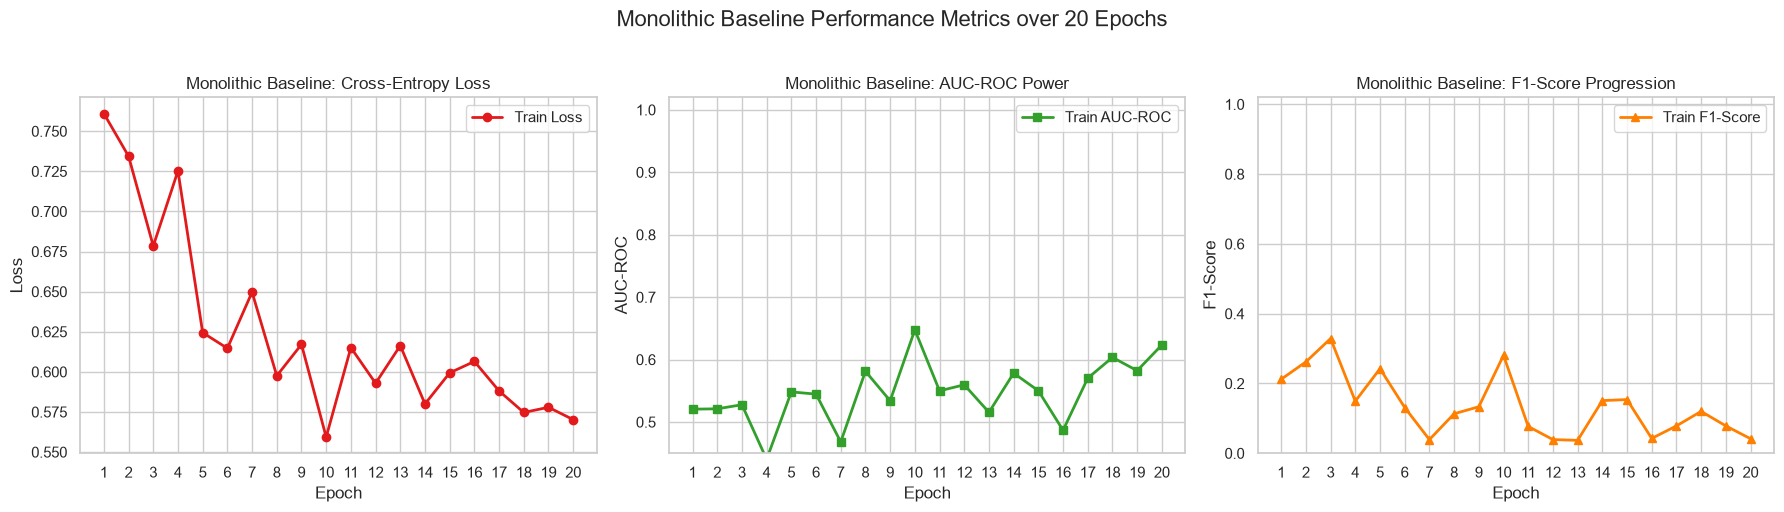

In [35]:
# ==============================================================================
# 3. BASELINE TRAINING PIPELINE (20 EPOCHS) WITH PLOTTING
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiation parameters
STATIC_INPUT_DIM = X_static_train.shape[1]
VITALS_INPUT_DIM = 6
LABS_INPUT_DIM   = 5
BATCH_SIZE       = 16

# Setup datasets and loaders
train_dataset = MonolithicClinicalDataset(X_static_train, X_sequential_clean, X_labs_clean, Y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Instantiate model, optimizer, and loss
baseline_model = MonolithicLSTM(
    static_dim=STATIC_INPUT_DIM, 
    vitals_dim=VITALS_INPUT_DIM, 
    labs_dim=LABS_INPUT_DIM
).to(device)

optimizer = optim.AdamW(baseline_model.parameters(), lr=0.0005, weight_decay=1e-3)
criterion = nn.BCELoss()

EPOCHS = 20

# Lists to track metrics over epochs for visualization
history = {
    'loss': [],
    'accuracy': [],
    'f1': [],
    'auc_roc': []
}

print(f"Beginning training on Monolithic Baseline for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    baseline_model.train()
    epoch_loss = 0.0
    total_samples = 0
    
    all_targets = []
    all_probabilities = []
    
    for batch in train_loader:
        x_s = batch['static'].to(device)
        x_v = batch['vitals'].to(device)
        x_l = batch['labs'].to(device)
        y   = batch['target'].to(device)
        
        optimizer.zero_grad()
        
        # Direct forward pass
        predictions = baseline_model(x_s, x_v, x_l)
        
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()
        
        # Tracking metrics
        epoch_loss += loss.item() * x_s.size(0)
        total_samples += x_s.size(0)
        
        all_targets.append(y.detach().cpu().numpy())
        all_probabilities.append(predictions.detach().cpu().numpy())
        
    # Epoch Metric Evaluations
    epoch_targets = np.concatenate(all_targets, axis=0)
    epoch_probs   = np.concatenate(all_probabilities, axis=0)
    epoch_preds   = (epoch_probs >= 0.5).astype(float)
    
    avg_loss = epoch_loss / total_samples
    accuracy = (epoch_preds == epoch_targets).mean() * 100
    f1 = f1_score(epoch_targets, epoch_preds, zero_division=0)
    
    try:
        auc_roc = roc_auc_score(epoch_targets, epoch_probs)
    except ValueError:
        auc_roc = 0.5
        
    # Append to history for plotting
    history['loss'].append(avg_loss)
    history['accuracy'].append(accuracy)
    history['f1'].append(f1)
    history['auc_roc'].append(auc_roc)
        
    # Print progress status update for every single epoch
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}% | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f}")

print("\n" + "="*60)
print("MONOLITHIC BASELINE TRAINING COMPLETE.")
print("="*60 + "\n")

# ==============================================================================
# GENERATE PRESENTATION METRIC PLOTS
# ==============================================================================
sns.set_theme(style="whitegrid")
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss Progression
axes[0].plot(epochs_range, history['loss'], 'o-', color='#e31a1c', linewidth=2, label='Train Loss')
axes[0].set_title('Monolithic Baseline: Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs_range)
axes[0].legend()

# Plot 2: AUC-ROC Power
axes[1].plot(epochs_range, history['auc_roc'], 's-', color='#33a02c', linewidth=2, label='Train AUC-ROC')
axes[1].set_title('Monolithic Baseline: AUC-ROC Power')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_xticks(epochs_range)
axes[1].set_ylim([0.45, 1.02])
axes[1].legend()

# Plot 3: F1-Score (Class Balance)
axes[2].plot(epochs_range, history['f1'], '^-', color='#ff7f00', linewidth=2, label='Train F1-Score')
axes[2].set_title('Monolithic Baseline: F1-Score Progression')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1-Score')
axes[2].set_xticks(epochs_range)
axes[2].set_ylim([0.0, 1.02])
axes[2].legend()

plt.suptitle('Monolithic Baseline Performance Metrics over 20 Epochs', y=1.02, fontsize=16)
plt.tight_layout()

# Save the baseline figure for your thesis/slides directory
plt.savefig('lstm_baseline_metrics.png', dpi=300, bbox_inches='tight')
plt.show()